# Sprint 1: Species coverage Analysis

Goal: analyse the merged Project Echo dtaset to understand recording counts, duration, and species imbalance, and recommend how to handle underrepresented species before training.

#### Setup

Libraries needed to scan folders, read audio metadata, and build the dataset table.

In [29]:
import os
import numpy as np
import glob
import pandas as pd
from tqdm import tqdm
import soundfile as sf

#### Function: Extract Audio Metadata

Scans a folder of audio files and records the species (from folder name), duration, and sample rate of each file.

In [6]:
# crating a function to scan a folder for audio files and collecting the key information about each file
def get_audio_metadata(root_dir): 
    data = [] 
    all_files = []
    for ext in ["*.wav", "*.mp3", "*.flac", "*.ogg"]:
        all_files.extend(glob.glob(os.path.join(root_dir, "**", ext), recursive=True))

    print(f"Found {len(all_files)} audio files. Extracting metadata...")

    # goin through every audio file and pulling out its details
    for file_path in tqdm(all_files):
        try:
            folder_name = os.path.basename(os.path.dirname(file_path)) # species name is the name of the folder the file is in

            # Reading the audio file's metadata 
            info = sf.info(file_path)
            duration = info.duration # length of the recording, in seconds
            samplerate = info.samplerate # audio quality/sample rate, in HZ

            # saving the file's info as one row 
            data.append({
                "path": file_path,
                "filename": os.path.basename(file_path),
                "label": folder_name,  
                "duration": duration,
                "samplerate": samplerate,
            })

        except Exception as e:
            # if file is corrupted or unreadable, skip it but also log the reason
            print(f"Error processing {file_path}: {e}")
            continue


    # Turn the list of rows into a proper table (DataFrame) for easy analysis
    return pd.DataFrame(data)

# Run the function on our downloaded dataset folder
df = get_audio_metadata("/Users/manishaa/Documents/Project Echo/Project-Echo/dataset")

print(df.shape)

df.head()

Found 8659 audio files. Extracting metadata...


100%|███████████████████████████████████| 8659/8659 [00:00<00:00, 20706.60it/s]

(8659, 5)


,path,filename,label,duration,samplerate
0,/Users/manishaa/Documents/Project Echo/Project...,t21.wav,Rhinella marina,2.969161,44100
1,/Users/manishaa/Documents/Project Echo/Project...,t34.wav,Rhinella marina,2.969161,44100
2,/Users/manishaa/Documents/Project Echo/Project...,t23.wav,Rhinella marina,2.969161,44100
3,/Users/manishaa/Documents/Project Echo/Project...,region_61.750-63.250.wav,Chenonetta jubata,1.500000,48000
4,/Users/manishaa/Documents/Project Echo/Project...,region_76.400-77.650.wav,Chenonetta jubata,1.250000,48000


#### Download Dataset from GCP

Pulls all audio files from the four project buckets into a local folder. Filenames are prefixed with bucket name to avoid files with duplicate bames silently overwriting each other.

In [9]:
from google.cloud import storage
import os
from tqdm import tqdm

os.environ["GCLOUD_PROJECT"] = "sit-23t1-project-echo-25288b9"
base_dir = "/Users/manishaa/Documents/Project Echo/Project-Echo/dataset_v2"  # new folder, so we don't mix with the old incomplete one

buckets = [
    'project_echo_bucket_1',
    'project_echo_bucket_2',
    'project_echo_bucket_3',
    'project_echo_birdclef'
]

storage_client = storage.Client()

def processing_bucket(bucket_name, storage_client, base_dir):
    print(f"\nProcessing bucket: {bucket_name}")
    bucket = storage_client.get_bucket(bucket_name)
    blobs = list(bucket.list_blobs())
    
    with tqdm(total=len(blobs), desc=f"Downloading {bucket_name}") as pbar:
        for blob in blobs:
            folder_name = blob.name.split('/')[0]
            file_name = '/'.join(blob.name.split('/')[1:])
            
            # Prefix the filename with the bucket name to guarantee uniqueness
            # e.g. "project_echo_bucket_2__track1.wav" instead of just "track1.wav"
            safe_file_name = f"{bucket_name}__{os.path.basename(file_name)}"
            
            local_dir = os.path.join(base_dir, folder_name)
            local_path = os.path.join(local_dir, safe_file_name)
            
            os.makedirs(local_dir, exist_ok=True)
            blob.download_to_filename(local_path)
            pbar.update(1)

for bucket_name in buckets:
    processing_bucket(bucket_name, storage_client, base_dir)

print("All files have been downloaded successfully (no overwrites this time)!")

/opt/miniconda3/envs/projectecho/lib/python3.9/site-packages/google/auth/__init__.py:54: FutureWarning: You are using a Python version 3.9 past its end of life. Google will update google-auth with critical bug fixes on a best-effort basis, but not with any other fixes or features. Please upgrade your Python version, and then update google-auth.
  warnings.warn(eol_message.format("3.9"), FutureWarning)
/opt/miniconda3/envs/projectecho/lib/python3.9/site-packages/google/oauth2/__init__.py:40: FutureWarning: You are using a Python version 3.9 past its end of life. Google will update google-auth with critical bug fixes on a best-effort basis, but not with any other fixes or features. Please upgrade your Python version, and then update google-auth.
  warnings.warn(eol_message.format("3.9"), FutureWarning)
/opt/miniconda3/envs/projectecho/lib/python3.9/site-packages/google/api_core/_python_version_support.py:242: FutureWarning: You are using a non-supported Python version (3.9.25). Google wi


Processing bucket: project_echo_bucket_1



Processing bucket: project_echo_bucket_2



Processing bucket: project_echo_bucket_3



Processing bucket: project_echo_birdclef


All files have been downloaded successfully (no overwrites this time)!


**Note:** An earlier version of this download (without the bucket-name prefix) silently overwrote files with matching names across buckets, cutting the dataset roughly in half without any error. Prefixing filenames with the source bucket fixed this.

#### Verify Download: File Types and Counts

Sanity check on what actually downlaoded, before trusting it for analysis.

In [14]:
import os
from collections import Counter

all_extensions = Counter()
for root, dirs, files in os.walk("/Users/manishaa/Documents/Project Echo/Project-Echo/dataset_v2"):    
    for f in files:
        ext = os.path.splitext(f)[1].lower()
        all_extensions[ext] += 1

for ext, count in all_extensions.most_common():
    print(ext, count)

.mp3 14397
.wav 631
.ogg 524
.ds_store 22


**Result:** ~15,552 audio files (mp3/wav/ogg) downloaded, closely matching the expected total across all four buckets. Confirms the overwrite issue is resolved.

#### Build the Full Metadata Table

Runs the extraction function across the entire downloaded dataset to get one row per recording.

In [15]:
df = get_audio_metadata("/Users/manishaa/Documents/Project Echo/Project-Echo/dataset_v2")
print(df.shape)
df.head()

Found 15552 audio files. Extracting metadata...


100%|█████████████████████████████████| 15552/15552 [00:00<00:00, 20135.79it/s]

(15552, 5)


,path,filename,label,duration,samplerate
0,/Users/manishaa/Documents/Project Echo/Project...,project_echo_bucket_1__t21.wav,Rhinella marina,2.969161,44100
1,/Users/manishaa/Documents/Project Echo/Project...,project_echo_bucket_1__t34.wav,Rhinella marina,2.969161,44100
2,/Users/manishaa/Documents/Project Echo/Project...,project_echo_bucket_1__t23.wav,Rhinella marina,2.969161,44100
3,/Users/manishaa/Documents/Project Echo/Project...,project_echo_bucket_1__region_76.400-77.650.wav,Chenonetta jubata,1.250000,48000
4,/Users/manishaa/Documents/Project Echo/Project...,project_echo_bucket_1__region_61.750-63.250.wav,Chenonetta jubata,1.500000,48000


**Result:** 15,552 recordings loaded successfully, each tagged with species, duration, and sample rate.

#### Recordings and Duration per Species

Core task requirement: how many recordings and how much total audio exists per species and which species are over/under-represented.

In [16]:
# How many species do we have, and how many recordings does each one have?
species_counts = df['label'].value_counts()

print(f"Total species: {df['label'].nunique()}")
print(f"Total recordings: {len(df)}")
print()
print("Top 10 most represented species:")
print(species_counts.head(10))
print()
print("Bottom 10 least represented species:")
print(species_counts.tail(10))
print()
print("Total duration of all recordings (hours):", df['duration'].sum() / 3600)
print()
print("Duration stats (seconds) per file:")
print(df['duration'].describe())

Total species: 123
Total recordings: 15552

Top 10 most represented species:
label
Rhipidura leucophrys       1292
Colluricincla harmonica    1214
Phylidonyris niger         1080
Rhipidura albiscapa         884
Dasyurus maculatus          520
Acanthiza pusilla           492
Cisticola exilis            422
Litoria inermis             422
Barnardius zonarius         404
Cophixalus infacetus        342
Name: count, dtype: int64

Bottom 10 least represented species:
label
Anhinga novaehollandiae     12
Ceyx azureus                10
Neophema pulchella          10
Pelecanus conspicillatus    10
Ptilinopus regina           10
Coracina papuensis          10
Entomyzon cyanotis          10
Cophixalus ornatus          10
Pachycephala simplex         6
Geopelia cuneata             4
Name: count, dtype: int64

Total duration of all recordings (hours): 17.801360971986018

Duration stats (seconds) per file:
count    15552.000000
mean         4.120685
std         26.038028
min          0.350000
25%  

**Result:** 123 species found. Recordings range from 1,292 (*Rhipidura leucophrys*) down to just 2 (*Geopelia cuneata*), a large gap between the most and least represented species. Most recordings are short (median ~2 seconds), though a few extreme outliers exist (max over 1,300 seconds).

#### Data Quality Check: Are Recordings Actually Duplicated?
The high totals compared to an earlier partial snapshot raised a question: is the same audio being counted twice? Testing this on the most common species first.

In [17]:
import hashlib

def file_hash(path):
    """Generate a quick fingerprint of a file's actual content."""
    with open(path, 'rb') as f:
        return hashlib.md5(f.read()).hexdigest()

# Check a sample first (hashing all 15,552 files takes a while, so let's sample this one species first)
sample = df[df['label'] == 'Rhipidura leucophrys'].copy()
sample['hash'] = sample['path'].apply(file_hash)

print(f"Total files for this species: {len(sample)}")
print(f"Unique file contents: {sample['hash'].nunique()}")

Total files for this species: 1292
Unique file contents: 1292


**Result:** All files for this species have unique content — no duplication. The dataset genuinely combines more source data than the earlier partial snapshot did.

#### Coverage by Source Bucket
Comparing how much each of the four original data sources contributes to the dataset and to species coverage.

In [18]:
# Extract which bucket each file came from, using the filename prefix we added
df['source_bucket'] = df['filename'].apply(lambda x: x.split('__')[0])

print("Recordings per source bucket:")
print(df['source_bucket'].value_counts())
print()
print("Species per source bucket:")
print(df.groupby('source_bucket')['label'].nunique())

Recordings per source bucket:
source_bucket
project_echo_bucket_3    7514
project_echo_bucket_2    7161
project_echo_birdclef     524
project_echo_bucket_1     353
Name: count, dtype: int64

Species per source bucket:
source_bucket
project_echo_birdclef      5
project_echo_bucket_1    118
project_echo_bucket_2    116
project_echo_bucket_3    118
Name: label, dtype: int64


**Result:** bucket_2 and bucket_3 are the two main sources, each covering nearly all species with thousands of recordings. bucket_1 is a small seed set. birdclef is narrow, covering only 5 species.

#### Which Species Does BirdCLEF Actually Cover?

In [19]:
birdclef_species = df[df['source_bucket'] == 'project_echo_birdclef']['label'].unique()
print(birdclef_species)

['jabwar' 'wiltur' 'sheowl' 'brant' 'spodov']


**Result:** The 5 birdclef species are labeled with short codes instead of proper scientific names, unlike every other folder in the dataset.

#### Data Quality Issue: Mislabeled Species Names
Checking whether these short-code species are actually duplicates of species already in the dataset under their real name.

In [20]:
real_names = {
    "jabwar": "Horornis diphone",
    "brant": "Branta bernicla nigricans",
    "sheowl": "Asio flammeus",
    "spodov": "Spilopelia chinensis",
    "wiltur": "Meleagris gallopavo"
}

for code, name in real_names.items():
    count = (df['label'] == name).sum()
    print(f"{code} -> {name}: {count} recordings already exist under the real name")

jabwar -> Horornis diphone: 0 recordings already exist under the real name
brant -> Branta bernicla nigricans: 0 recordings already exist under the real name
sheowl -> Asio flammeus: 0 recordings already exist under the real name
spodov -> Spilopelia chinensis: 14 recordings already exist under the real name
wiltur -> Meleagris gallopavo: 0 recordings already exist under the real name


**Result:** 4 of the 5 are genuinely new species. But `spodov` is a duplicate, recordings already exist under its real name, *Spilopelia chinensis*.

#### Fix: Merge Mislabeled Species into Correct Names

In [21]:
# Fix the mislabeled species: replace short codes with proper scientific names
real_names = {
    "jabwar": "Horornis diphone",
    "brant": "Branta bernicla nigricans",
    "sheowl": "Asio flammeus",
    "spodov": "Spilopelia chinensis",
    "wiltur": "Meleagris gallopavo"
}

df['label'] = df['label'].replace(real_names)

# Re-check species count and top/bottom counts now that labels are corrected
print(f"Total species after fixing labels: {df['label'].nunique()}")
print()
species_counts = df['label'].value_counts()
print("Top 10:")
print(species_counts.head(10))
print()
print("Bottom 10:")
print(species_counts.tail(10))

Total species after fixing labels: 122

Top 10:
label
Rhipidura leucophrys       1292
Colluricincla harmonica    1214
Phylidonyris niger         1080
Rhipidura albiscapa         884
Dasyurus maculatus          520
Acanthiza pusilla           492
Cisticola exilis            422
Litoria inermis             422
Barnardius zonarius         404
Cophixalus infacetus        342
Name: count, dtype: int64

Bottom 10:
label
Egretta novaehollandiae     12
Ceyx azureus                10
Neophema pulchella          10
Pelecanus conspicillatus    10
Coracina papuensis          10
Ptilinopus regina           10
Entomyzon cyanotis          10
Cophixalus ornatus          10
Pachycephala simplex         6
Geopelia cuneata             4
Name: count, dtype: int64


**Result:** Species count corrected from 123 to 122 after merging the duplicate label. This is the accurate, final species count.

#### Visualisation: Recordings per Species
Charting the full species distribution to make the imbalance visible at a glance.

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns

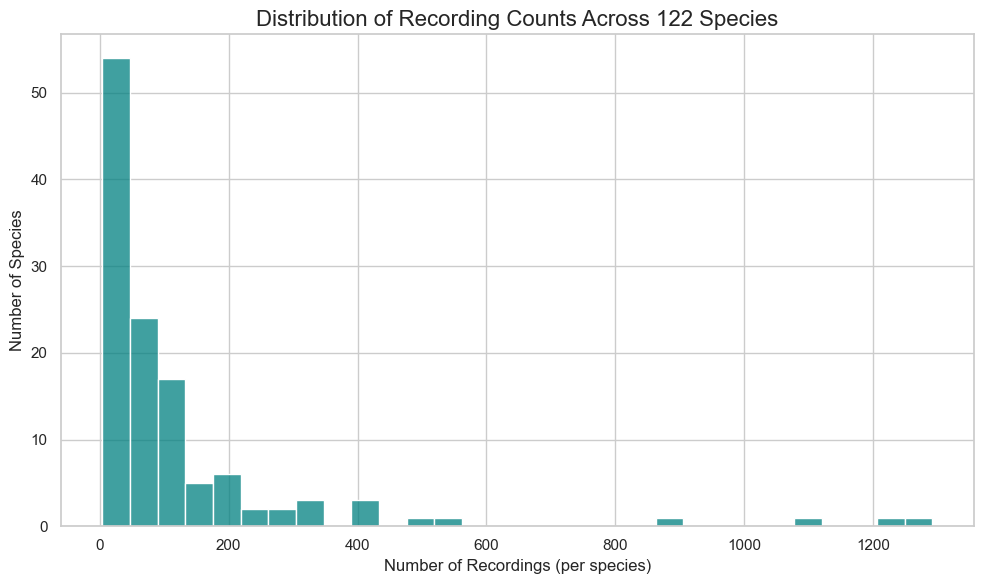

In [33]:
# histogram showing how many species fall into each recording-count range
fig, ax = plt.subplots(figsize=(10, 6))
sns.histplot(species_counts.values, bins=30, color="teal", ax=ax)
ax.set_title(f"Distribution of Recording Counts Across {df['label'].nunique()} Species", fontsize=16)
ax.set_xlabel("Number of Recordings (per species)")
ax.set_ylabel("Number of Species")
plt.tight_layout()
plt.savefig("species_distribution.png", dpi=150)
plt.show()

**Result:** The above distribution is heavily right-skewed, most species have a low-to-moderate number of recordings, while a small handful stretch out to 1,000+ recordings. This "long tail" shape is the clearest visual evidence of the imbalance: a few species dominate the dataset while most sit far behind them.

#### Visualisation: Duration Distribution
Checking how long recordings typically are, and how extreme the outliers are.

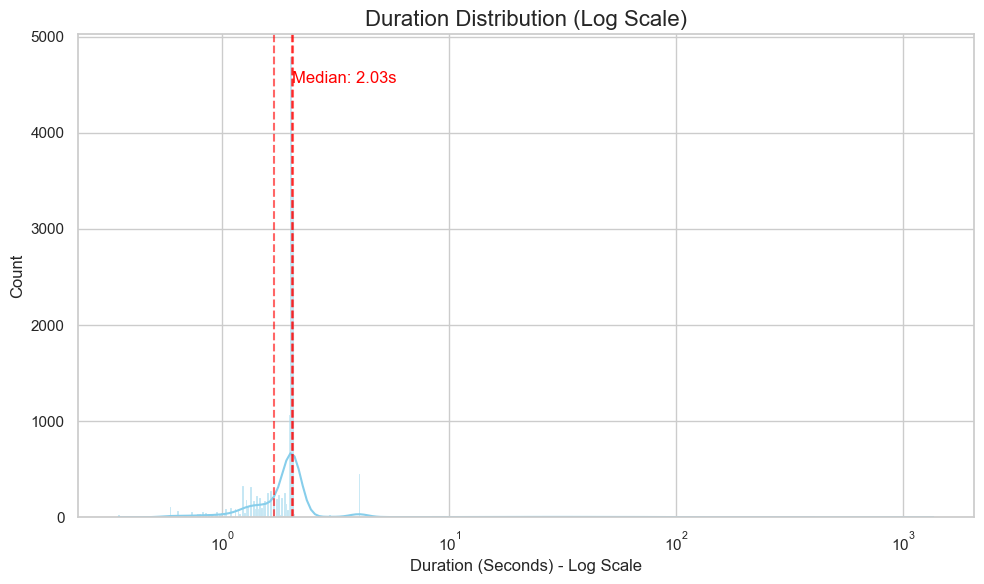

In [25]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.histplot(data=df, x="duration", kde=True, ax=ax, color="skyblue", log_scale=True)
ax.set_title("Duration Distribution (Log Scale)", fontsize=16)
ax.set_xlabel("Duration (Seconds) - Log Scale")

quantiles = df['duration'].quantile([0.25, 0.5, 0.75])
for q in quantiles:
    ax.axvline(q, color="red", linestyle="--", alpha=0.6)
ax.text(quantiles[0.5], ax.get_ylim()[1] * 0.9, f"Median: {quantiles[0.5]:.2f}s", color="red")

plt.tight_layout()
plt.savefig("duration_distribution.png", dpi=150)
plt.show()

**Result:** Most recordings cluster tightly around 1.5–2 seconds (the median), which matches the short-clip nature of bioacoustic detections. A small number of extreme outliers stretch well beyond this, some recordings run over 1,000 seconds, which pulled the mean duration noticeably above the median. These outliers are worth flagging separately, since they behave very differently from typical clips and may need special handling before training.

#### Visualisation: Most vs Least Represented Species
Side-by-side comparison of the top 10 and bottom 10 species by recording count.

/var/folders/gk/5qk109_j5rs6lh_lfxkb6lr40000gn/T/ipykernel_46758/2290666274.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top10.values, y=top10.index, ax=axes[0], palette="Greens_r")
/var/folders/gk/5qk109_j5rs6lh_lfxkb6lr40000gn/T/ipykernel_46758/2290666274.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=bottom10.values, y=bottom10.index, ax=axes[1], palette="Reds_r")


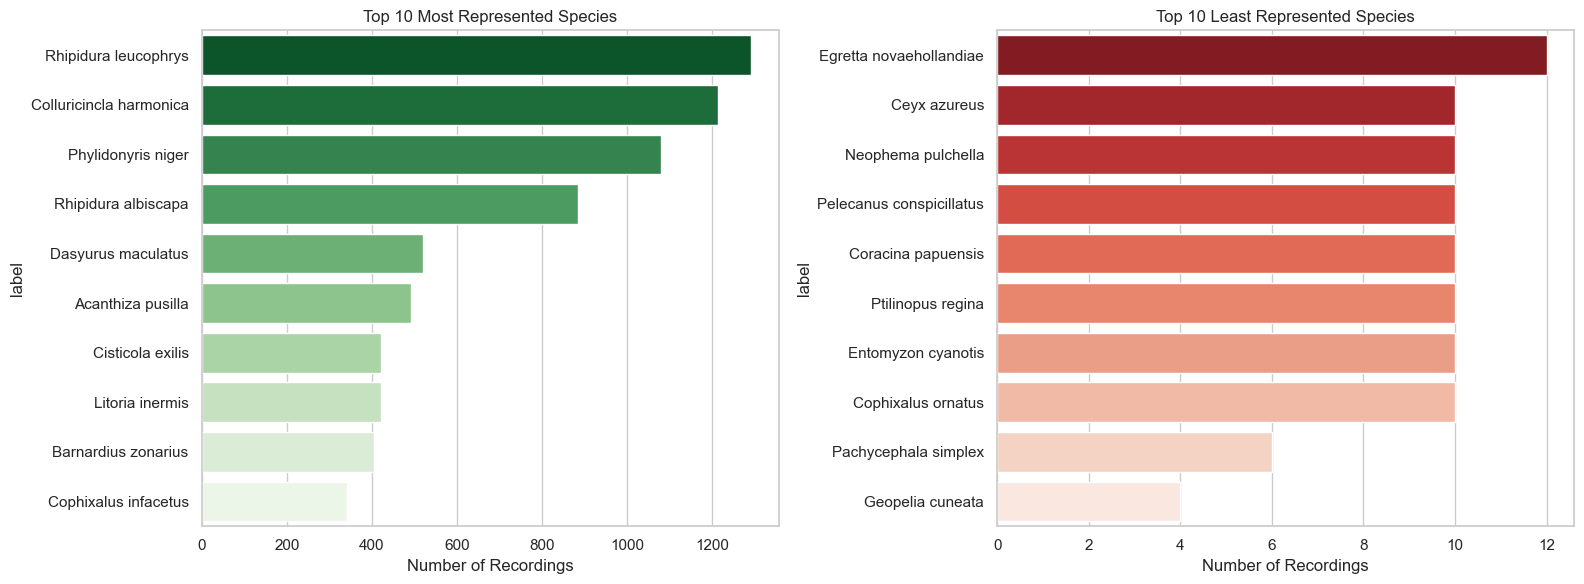

In [26]:
top10 = species_counts.head(10)
bottom10 = species_counts.tail(10)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(x=top10.values, y=top10.index, ax=axes[0], palette="Greens_r")
axes[0].set_title("Top 10 Most Represented Species")
axes[0].set_xlabel("Number of Recordings")

sns.barplot(x=bottom10.values, y=bottom10.index, ax=axes[1], palette="Reds_r")
axes[1].set_title("Top 10 Least Represented Species")
axes[1].set_xlabel("Number of Recordings")

plt.tight_layout()
plt.savefig("imbalance_comparison.png", dpi=150)
plt.show()

**Result:** from the above plot, the most represented species (*Rhipidura leucophrys*, 1,292 recordings) has over 100x more data than the least represented (*Geopelia cuneata*, 4 recordings). Every species in the "least represented" group sits in the single-to-low-double digits, while the "most represented" group is in the hundreds to low thousands.

#### Visualisation: Species coverage vs Recording per source
Showing how much each data source contributes to the overall dataset.

/var/folders/gk/5qk109_j5rs6lh_lfxkb6lr40000gn/T/ipykernel_46758/4100657598.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=source_recording_counts.values, y=source_recording_counts.index, ax=axes[0], palette="mako")
/var/folders/gk/5qk109_j5rs6lh_lfxkb6lr40000gn/T/ipykernel_46758/4100657598.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=source_species_counts.values, y=source_species_counts.index, ax=axes[1], palette="mako")


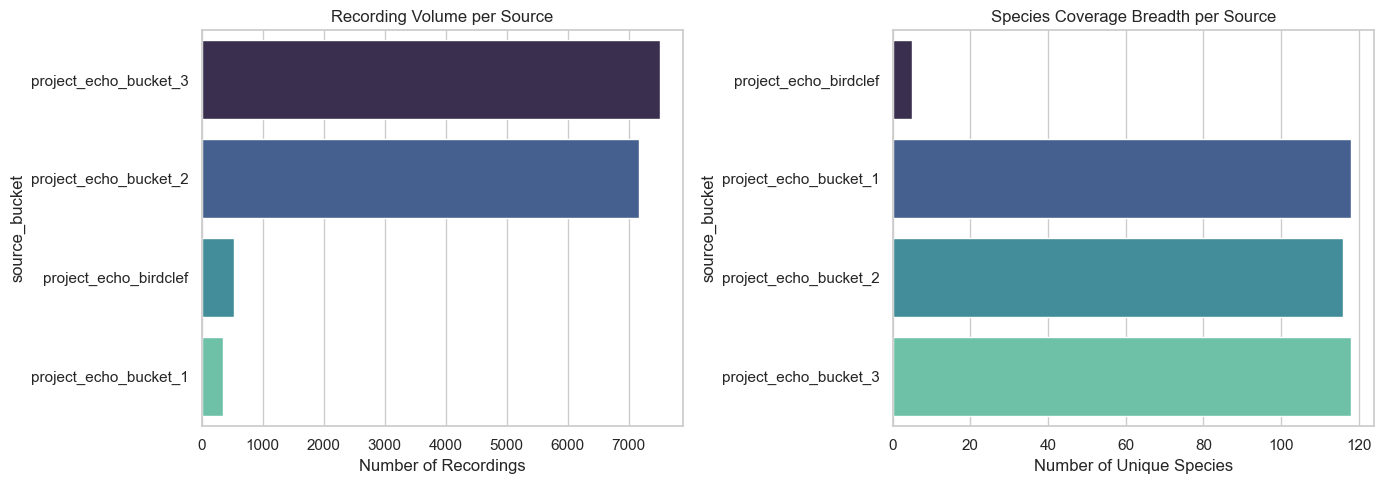

In [31]:
# Species coverage vs recording volume per source, side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

source_recording_counts = df['source_bucket'].value_counts()
source_species_counts = df.groupby('source_bucket')['label'].nunique()

sns.barplot(x=source_recording_counts.values, y=source_recording_counts.index, ax=axes[0], palette="mako")
axes[0].set_title("Recording Volume per Source")
axes[0].set_xlabel("Number of Recordings")

sns.barplot(x=source_species_counts.values, y=source_species_counts.index, ax=axes[1], palette="mako")
axes[1].set_title("Species Coverage Breadth per Source")
axes[1].set_xlabel("Number of Unique Species")

plt.tight_layout()
plt.savefig("source_bucket_coverage.png", dpi=150)
plt.show()

**Result:** bucket_2 and bucket_3 are the two dominant sources, both by volume (thousands of recordings each) and species breadth (116–118 species). bucket_1 is notable for being efficient: despite having only 353 recordings, it still covers 118 species, suggesting it functions as a small seed/reference set. birdclef is the opposite: narrow and targeted, contributing to only 5 species, and as found earlier, using inconsistent labeling (short codes instead of scientific names).

#### Recommendations for Handling the Imbalance

The dataset has a real imbalance problem. The most common species has over 300 times more recordings than the least common one. Training a model on this data as it stands would likely make it very good at recognising common species and bad at recognising rare ones, since it barely sees them.

A few practical ways to handle this before training:

**1. Oversample the rare species.** For species with only a handful of recordings (like the ones with 4 to 12 files), simply repeating those files more times during training gives the model more chances to learn from them, without needing any new data.

**2. Use audio augmentation on rare species specifically.** Techniques like pitch shifting, time stretching, and adding background noise can create new, slightly different versions of the same recording. This is especially useful for the rare species, since it stretches a small number of real recordings into a larger, more varied training set.

**3. Downsample or cap the most common species.** Species like *Rhipidura leucophrys* have so many recordings that they could end up dominating training just by sheer volume. Setting a reasonable cap (using only a random subset of their recordings each epoch, for example) stops the model from over-focusing on species that are already well represented.

**4. Use a weighted loss function during training.** Instead of changing the data itself, the model can be told to pay more attention to mistakes on rare species and less to mistakes on common ones. This is a standard fix for imbalanced classification problems and can be combined with the data-level fixes above.

**5. Fix the mislabeled BirdCLEF species before using them.** As found earlier, one BirdCLEF species (`spodov`) was actually a duplicate of an existing species under a different name. This kind of labeling issue should be checked and cleaned up first, since it silently under-counts real data for that species.

**6. Handle the extreme-duration outliers separately.** A few recordings are far longer than the rest (over 1,000 seconds, compared to a typical 2-second clip). These should be reviewed individually. They may need to be trimmed into shorter clips, or excluded if they are not genuine short-call recordings, so they do not distort training.

None of these fixes require collecting brand new data, they can all be done with what is already in the dataset. The most practical starting point is probably a mix of oversampling and augmentation for the rarest species, combined with a capped or weighted approach for the most common ones, so the model gets a fairer shot at learning every species properly.